In [41]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
config = {
    "sigma_meas": 10.0,
    "sigma_init": 10.0,
    "e_v": 5.0,         
    "q": 1.0,          
    "N_particles": 15000
}

In [43]:
def generate_ground_truth(T=500, dt=0.01):
    t = np.arange(0, T, dt)
    v0 = 50.0        # m/s
    ax = 0.2         # m/s^2
    A = 100.0        # amplitude lateral
    omega = 0.05     # rad/s

    x = v0*t + 0.5*ax*t**2
    y = A*np.sin(omega*t)

    vx = np.gradient(x,dt)
    vy = np.gradient(y,dt)

    return t, x, y, vx, vy

t, x, y, vx, vy = generate_ground_truth()

In [44]:
def radar_measurements(t_truth, x, y, sigma, rate = 1.0):
    dt_meas = 1 / rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)

    noise = np.random.randn(len(t_meas),2)*sigma

    z = np.column_stack((x_meas, y_meas)) + noise

    return t_meas, z

t_meas, z = radar_measurements(t, x, y, config["sigma_meas"])

In [45]:
def apply_missing_data(z, missing_prob = 0.1):
    mask = np.random.rand(len(z))> missing_prob
    z_missing = z.copy()
    z_missing[~mask]=np.nan

    return z_missing, mask

z_missing, mask = apply_missing_data(z)

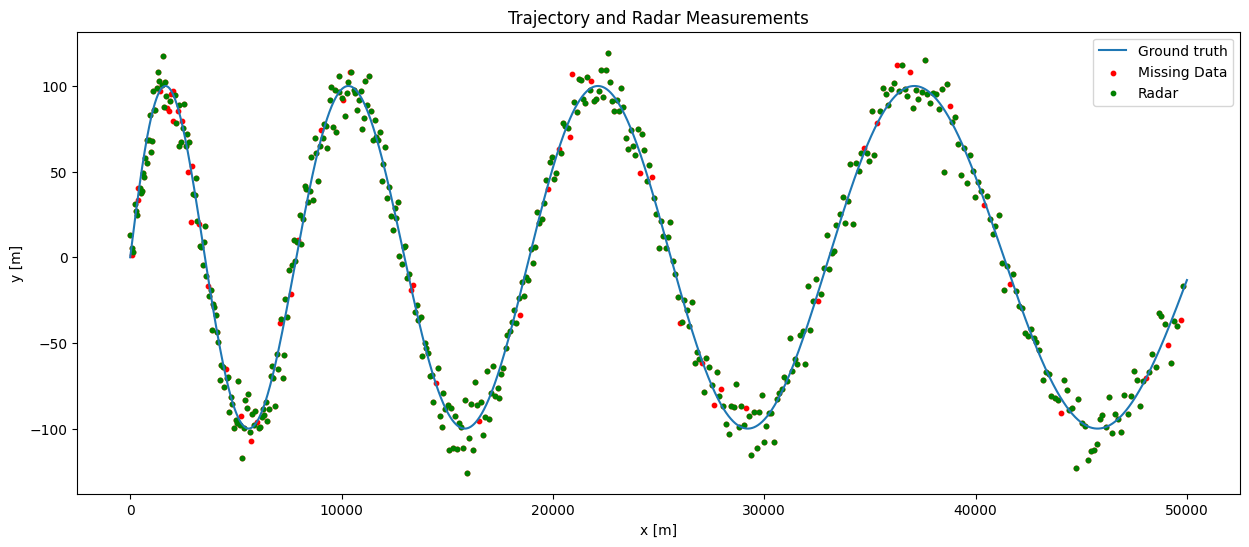

In [46]:
plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z[:,0], z[:,1], s = 10, label = "Missing Data", color = "red")
plt.scatter(z_missing[:,0], z_missing[:,1], s = 10, label = "Radar", color = "green")
plt.legend()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajectory and Radar Measurements")
plt.show()

In [47]:
def init_kalman(z, vx0, vy0, config):

    sigma = config["sigma_meas"]
    
    x0 = np.array([z[0, 0], z[0, 1], vx0, vy0]).reshape(-1, 1)
    P0 = np.eye(4) * 1e6
    
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])
    
    R = np.eye(2) * sigma**2

    return x0, P0, H, R

In [48]:
def run_kalman_filter(t_meas, z_missing, x_hat, P, H, R, q) :

    x_estimates = []
    x_estimates.append(x_hat.copy())
    
    for k in range(1, len(t_meas)) :
    
        dt = t_meas[k] - t_meas[k-1]
    
        F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        
        Q = q * np.array([
            [dt**4/4, 0, dt**3/2, 0],
            [0, dt**4/4, 0, dt**3/2],
            [dt**3/2, 0, dt**2, 0],
            [0, dt**3/2, 0, dt**2]
        ])
    
        x_hat = F @ x_hat
        P = F @ P @ F.T + Q
    
        z_k = z_missing[k]

        if not np.isnan(z_k).any() :
            z_k = z_k.reshape((2,1))
            y_k = z_k - H @ x_hat
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)
            x_hat = x_hat + K @ y_k
            P = (np.eye(4) - K @ H) @ P
            
        x_estimates.append(x_hat.copy())
    return np.array(x_estimates)

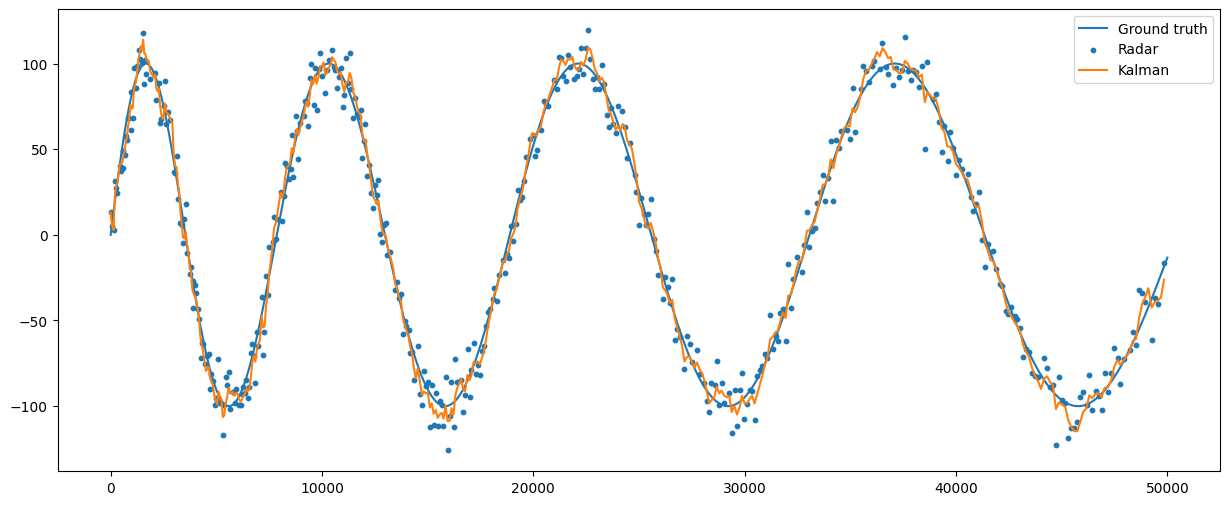

In [49]:
x0, P0, H, R = init_kalman(z, vx[0], vy[0], config)
x_kalman = run_kalman_filter(t_meas, z_missing, x0, P0, H, R, config["q"]).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_missing[:,0], z_missing[:,1], s= 10, label = "Radar")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "Kalman")
plt.legend()
plt.show()

In [50]:
def init_particles(z, vx0, vy0, config):
    
    N = config["N_particles"]
    e_v = config["e_v"]
    sigma_init = config["sigma_init"]
    
    particles = np.zeros((N, 4))
    
    particles[:, 0] = z[0, 0] + np.random.randn(N) * sigma_init
    particles[:, 1] = z[0, 1] + np.random.randn(N) * sigma_init
    particles[:, 2] = vx0 + np.random.randn(N) * e_v
    particles[:, 3] = vy0 + np.random.randn(N) * e_v
    
    weights = np.ones(N) / N

    return particles, weights

In [51]:
def predict_particles(particles, dt, q) :
    N = particles.shape[0]

    noise_pos = np.random.randn(N, 2) * np.sqrt(q) * dt**2 / 2
    noise_vel = np.random.randn(N, 2) * np.sqrt(q) * dt

    particles[:, 0] += particles[:, 2] * dt + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + noise_pos[:, 1]
    particles[:, 2] += noise_vel[:, 0]
    particles[:, 3] += noise_vel[:, 1]

    return particles

In [52]:
def update_weights(particles, weights, z, sigma) :
    diffs = particles[:, :2] - z.reshape(1, 2)
    distances_sq = np.sum(diffs**2, axis = 1)

    log_w = -0.5 * distances_sq / sigma**2
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [53]:
def N_eff(weights) :
    return 1. / np.sum(weights**2)

In [54]:
def resample(particles, weights) :
    N = len(weights)
    positions = (np.arange(N) + np.random.rand()) / N

    indexes = np.zeros(N, dtype = int)
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0

    while i < N :
        if positions[i] < cumulative_sum[j] :
            indexes[i] = j
            i += 1  
        else :
            j += 1

    particles[:] = particles[indexes]
    weights.fill(1 / N)

    return particles, weights

In [55]:
def estimate(particles, weights) :
    return np.average(particles, weights = weights, axis = 0)

In [56]:
def run_particle_filter(t_meas, z_missing, particles, weights, q, sigma) :

    estimates = []
    x_est0 = np.average(particles, weights=weights, axis=0)
    estimates.append(x_est0.copy())
    
    for k in range(1, len(t_meas)) :
        dt = t_meas[k] - t_meas[k-1]
    
        particles = predict_particles(particles, dt, q)
    
        if not np.isnan(z.any()) :
            weights = update_weights(particles, weights, z[k], sigma)
    
            if N_eff(weights) < config["N_particles"] * 0.5 :
                particles, weights = resample(particles, weights)
    
        x_hat = estimate(particles, weights)
        estimates.append(x_hat.copy())
    return np.array(estimates)

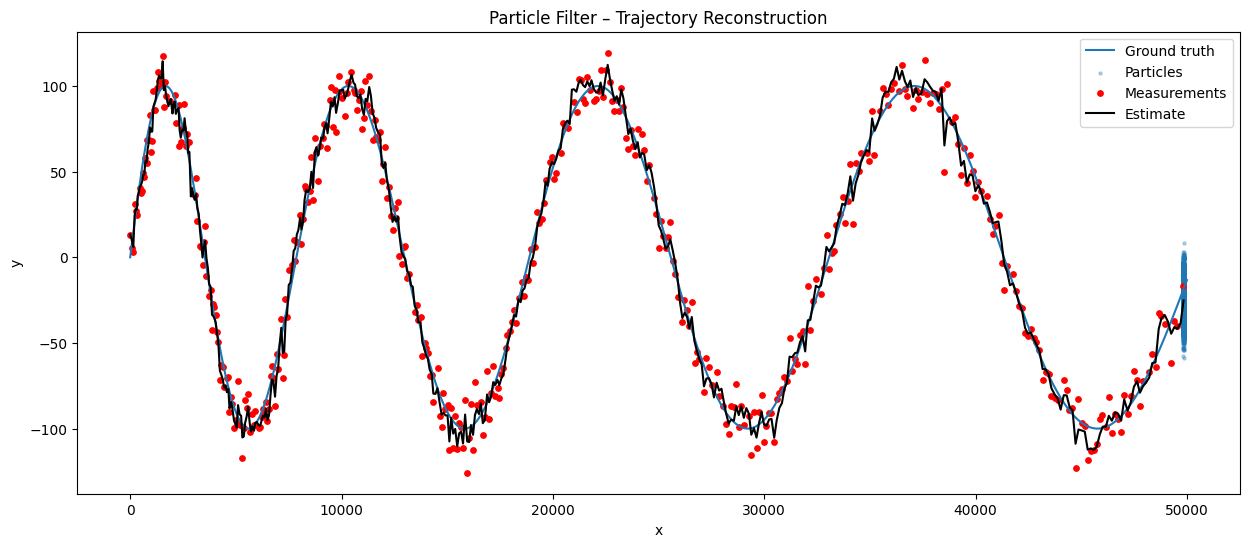

In [57]:
particles, weights = init_particles(z, vx[0], vy[0], config)
x_pf = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_meas"])

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_missing[:, 0], z_missing[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()

In [58]:
def rms_position(x_est, x_true) :
    error = x_est[:, :2] - x_true[:, :2]
    return np.sqrt(np.mean(np.sum(error**2, axis = 1)))

In [59]:
x_true = np.column_stack((
    np.interp(t_meas, t, x),
    np.interp(t_meas, t, y)
))

In [60]:
rms_kalman = rms_position(x_kalman, x_true)
rms_pf = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman)
print("RMS Particle Filter: ", rms_pf)

RMS Kalman:  8.289299336788574
RMS Particle Filter:  9.320364125721836


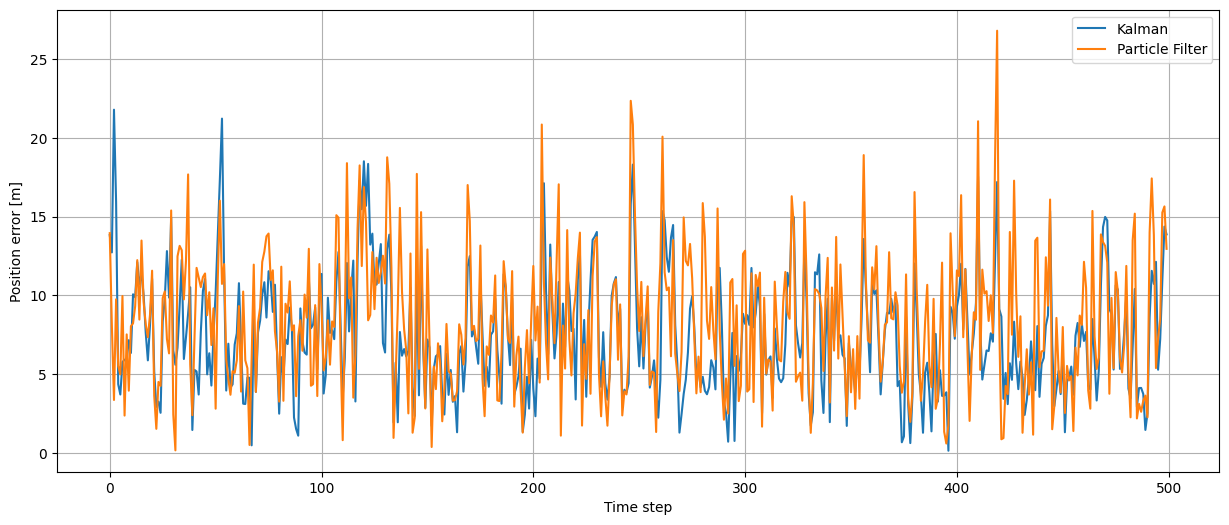

In [61]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [62]:
sigma_values = [5, 10, 20, 50, 100, 200, 500, 1000, 1500]

rms_kalman_list = []
rms_pf_list = []

for sigma in sigma_values :
    config["sigma_meas"] = sigma
    config["sigma_init"] = sigma
    
    t_meas, z = radar_measurements(t, x, y, rate = 1, sigma = sigma)

    x0, P0, H, R = init_kalman(z, vx[0], vy[0], config)
    x_kalman_estimates = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

    particles, weights = init_particles(z, vx[0], vy[0], config)
    x_pf_estimates = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_meas"])

    x_true = np.column_stack((
        np.interp(t_meas, t, x),
        np.interp(t_meas, t, y)
    ))

    rms_kalman_list.append(rms_position(x_kalman_estimates, x_true))
    rms_pf_list.append(rms_position(x_pf_estimates, x_true))

config["sigma_meas"] = 10
config["sigma_init"] = 10

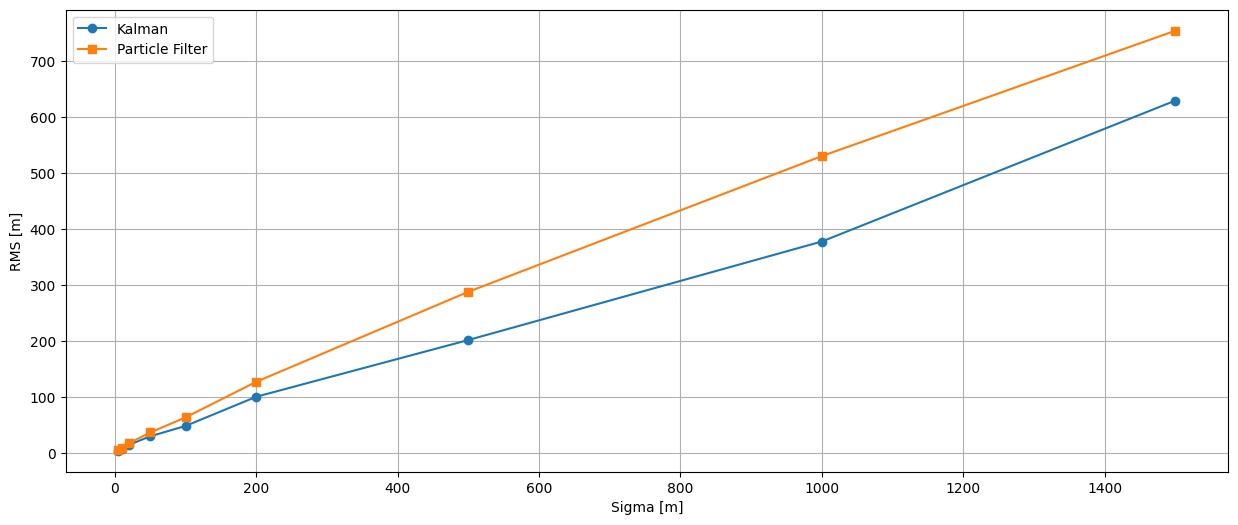

In [63]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_values, rms_kalman_list, 'o-', label = 'Kalman')
plt.plot(sigma_values, rms_pf_list, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m]')
plt.ylabel('RMS [m]')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
def radar_measurements_outliers(t_truth, x, y, sigma, rate = 1, p_outlier = 0.1, outlier_scale = 10):
    dt_meas = 1/rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)

    noise = np.random.randn(len(t_meas), 2) * sigma

    outliers = np.random.rand(len(t_meas)) < p_outlier
    noise[outliers] += np.random.randn(np.sum(outliers), 2) * sigma * outlier_scale

    z = np.column_stack((x_meas, y_meas)) + noise
    return t_meas, z

t_meas, z = radar_measurements_outliers(t, x, y, config["sigma_meas"])

In [65]:
x0, P0, H, R = init_kalman(z, vx[0], vy[0], config)
x_kalman = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

particles, weights = init_particles(z, vx[0], vy[0], config)
x_pf = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_meas"])

In [66]:
rms_kalman = rms_position(x_kalman, x_true)
rms_pf = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman)
print("RMS Particle Filter: ", rms_pf)

RMS Kalman:  24.556688230014906
RMS Particle Filter:  23.69990024487471


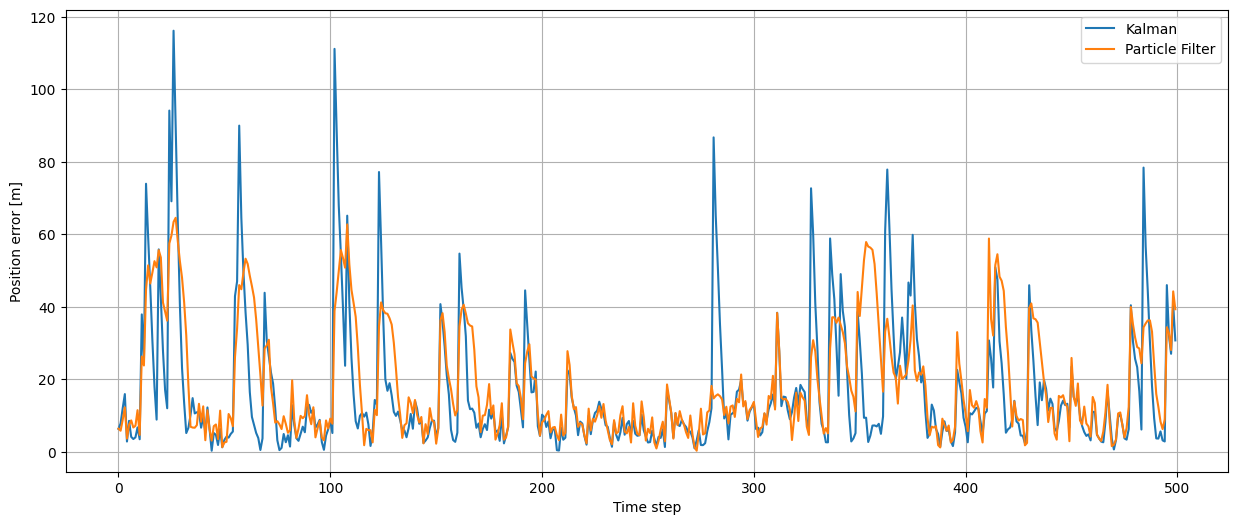

In [67]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [68]:
sigma_values = [5, 10, 20, 50, 100, 200, 500, 1000, 1500]

rms_kalman_list = []
rms_pf_list = []

for sigma in sigma_values :
    config["sigma_meas"] = sigma
    config["sigma_init"] = sigma
    
    t_meas, z = radar_measurements_outliers(t, x, y, config["sigma_meas"])

    x0, P0, H, R = init_kalman(z, vx[0], vy[0], config)
    x_kalman_estimates = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

    particles, weights = init_particles(z, vx[0], vy[0], config)
    x_pf_estimates = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_meas"])

    x_true = np.column_stack((
        np.interp(t_meas, t, x),
        np.interp(t_meas, t, y)
    ))

    rms_kalman_list.append(rms_position(x_kalman_estimates, x_true))
    rms_pf_list.append(rms_position(x_pf_estimates, x_true))

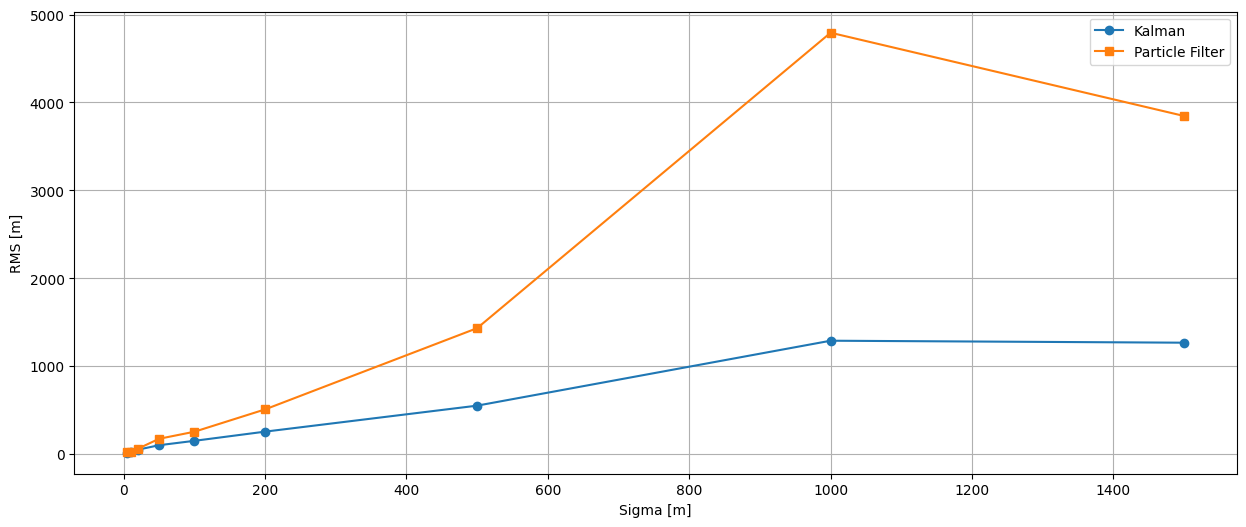

In [69]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_values, rms_kalman_list, 'o-', label = 'Kalman')
plt.plot(sigma_values, rms_pf_list, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m]')
plt.ylabel('RMS [m]')
plt.legend()
plt.grid(True)
plt.show()